In [ ]:
# Localiza la raíz del repositorio subiendo desde donde se ejecute el notebook,
# para no depender de una ruta fija de una máquina concreta.
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
while not ((PROJECT_DIR / "data").exists() and (PROJECT_DIR / "notebooks").exists()):
    PROJECT_DIR = PROJECT_DIR.parent

# 1. Importación

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
train_df = pd.read_csv(f"{PROJECT_DIR}/data/processed/madrid/listings_train.csv")
test_df = pd.read_csv(f"{PROJECT_DIR}/data/processed/madrid/listings_test.csv")
train_df.shape, test_df.shape

((15159, 95), (3790, 95))

## 2. ¿Qué modelos vamos a probar?

Los mismos cuatro que en Barcelona, por el mismo motivo: `Ridge` como referencia lineal regularizada (ya se vio en `03_model_baseline.ipynb` que una regresión lineal simple sufre de multicolinealidad severa aquí, todavía más que en Barcelona), y tres modelos de árboles — `Random Forest`, `Extra Trees` y `Hist Gradient Boosting` — que no se ven afectados por esa multicolinealidad ni necesitan escalar variables.

## 3. Preparación de X e y

### 3.1 Identificadores, objetivo y columnas de fuga

In [3]:
id_cols = ["id", "host_id", "host_profile_id"]
target_col = "price"
leakage_cols = ["price_log", "price_per_accommodate", "price_per_min_night"]
feature_cols = [c for c in train_df.columns if c not in id_cols + [target_col] + leakage_cols]

len(feature_cols)

88

### 3.2 X e y

In [4]:
X_train, y_train = train_df[feature_cols].copy(), train_df[target_col].copy()
X_test, y_test = test_df[feature_cols].copy(), test_df[target_col].copy()

X_train.shape, X_test.shape

((15159, 88), (3790, 88))

### 3.3 Booleanas a 0/1

In [5]:
bool_cols = X_train.select_dtypes(include="bool").columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

len(bool_cols)

57

### 3.4 Nulos: sin tratar todavía

In [6]:
X_train.isnull().sum()[X_train.isnull().sum() > 0]

review_scores_rating      2057
listing_age_days          2057
days_since_last_review    2057
dtype: int64

Igual que en Barcelona: los modelos de árboles de `scikit-learn` no aceptan `NaN` directamente salvo `HistGradientBoostingRegressor` (que sí los admite de forma nativa), así que `Ridge`/`Random Forest`/`Extra Trees` llevan un `SimpleImputer` dentro de su propio `Pipeline` (sección 4.2), no aquí.

## 4. Pipelines

### 4.1 Objetivo: `log1p(price)`

In [7]:
y_train_log = np.log1p(y_train)

### 4.2 Un `Pipeline` por modelo

In [8]:
pipelines = {
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
    ]),
    "Extra Trees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(random_state=42, n_jobs=-1)),
    ]),
    "Hist Gradient Boosting": Pipeline([
        ("model", HistGradientBoostingRegressor(random_state=42)),
    ]),
}

list(pipelines.keys())

['Ridge', 'Random Forest', 'Extra Trees', 'Hist Gradient Boosting']

Con hiperparámetros por defecto en los cuatro por ahora: el ajuste fino es la sección 6, después de haber elegido con cuál quedarse.

## 5. Entrenamiento y comparación entre modelos

### 5.1 Función `evaluate` y validación cruzada manual

In [9]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"modelo": name, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

### 5.2 Comparar los cuatro con 5-fold CV

In [10]:
from sklearn.model_selection import KFold

def cv_evaluate(pipeline, X, y_log, name, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr_log, y_val_log = y_log.iloc[train_idx], y_log.iloc[val_idx]
        pipeline.fit(X_tr, y_tr_log)
        pred = np.expm1(pipeline.predict(X_val))
        y_val = np.expm1(y_val_log)
        scores.append(evaluate(y_val, pred, name))
    return pd.DataFrame(scores).drop(columns="modelo").mean()

cv_rows = []
for name, pipe in pipelines.items():
    scores = cv_evaluate(pipe, X_train, y_train_log, name)
    scores["modelo"] = name
    cv_rows.append(scores)

cv_results = pd.DataFrame(cv_rows).set_index("modelo")
cv_results.round(2)

/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.p

/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.p

,RMSE,MAE,R2,MAPE
modelo,,,,
Ridge,191.35,51.45,0.29,30.07
Random Forest,181.49,45.06,0.38,25.59
Extra Trees,182.36,45.58,0.37,25.66
Hist Gradient Boosting,181.40,44.90,0.38,25.52


### 5.3 Interpretación

Con hiperparámetros por defecto, los tres modelos de árboles quedan prácticamente empatados (R²=0.37-0.38), con `Random Forest` (0.38) y `Hist Gradient Boosting` (0.38) por delante de `Extra Trees` (0.37) por un margen mínimo. `Ridge` (0.29) queda por detrás de los tres, pero mucho más cerca que en Barcelona — la regularización L2 le sienta bien a la multicolinealidad severa de la sección 3, aunque no le basta para alcanzar a los árboles. La sección 6 afina los tres modelos de árboles de todos modos, no solo el que gane aquí, por la misma lección aprendida en Barcelona.

## 6. Ajuste de hiperparámetros

Mismo criterio que en Barcelona: `RandomizedSearchCV` con 15 combinaciones y 3 folds por modelo (45 entrenamientos cada uno), sobre `y_train_log` con `scoring="r2"`, para los tres modelos de árboles — no solo el que gane por defecto en la sección 5, siguiendo la misma lección aprendida en Barcelona (afinar solo el "ganador" inicial habría dejado la comparación incompleta si el ranking cambia al afinar).

### 6.1 Random Forest

In [11]:
rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}

rf_search = RandomizedSearchCV(
    pipelines["Random Forest"], rf_param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1,
)
rf_search.fit(X_train, y_train_log)

print(rf_search.best_params_)
print(rf_search.best_score_)

{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None}
0.7502251739983189


### 6.2 Extra Trees

In [12]:
et_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}

et_search = RandomizedSearchCV(
    pipelines["Extra Trees"], et_param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1,
)
et_search.fit(X_train, y_train_log)

print(et_search.best_params_)
print(et_search.best_score_)

/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None}
0.7412019824400415


### 6.3 Hist Gradient Boosting

In [13]:
hgb_param_dist = {
    "model__max_iter": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_leaf_nodes": [15, 31, 63, 127],
    "model__l2_regularization": [0, 0.1, 1.0],
}

hgb_search = RandomizedSearchCV(
    pipelines["Hist Gradient Boosting"], hgb_param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1,
)
hgb_search.fit(X_train, y_train_log)

print(hgb_search.best_params_)
print(hgb_search.best_score_)

{'model__max_leaf_nodes': 63, 'model__max_iter': 300, 'model__max_depth': 10, 'model__learning_rate': 0.05, 'model__l2_regularization': 0}
0.7604940910768865


### 6.4 Resumen

| Modelo | Mejor R² (CV, log-precio) | Hiperparámetros ganadores |
|---|---|---|
| Random Forest | 0.750 | `n_estimators=500, max_depth=None, min_samples_split=2, min_samples_leaf=1, max_features=0.5` |
| Extra Trees | 0.741 | `n_estimators=500, max_depth=None, min_samples_split=2, min_samples_leaf=1, max_features=0.5` |
| Hist Gradient Boosting | **0.760** | `max_leaf_nodes=63, max_iter=300, max_depth=10, learning_rate=0.05, l2_regularization=0` |

Este R² está calculado en escala logarítmica (el `scoring="r2"` de `RandomizedSearchCV` compara directamente contra `y_train_log`, no contra el precio en euros), así que no es comparable con la tabla de la sección 5 — se retoma la comparación en euros en la sección 7. `Hist Gradient Boosting` gana con algo de margen sobre los otros dos también aquí, igual que en Barcelona.

## 7. Elegir el modelo final

### 7.1 Comparar en euros con los mejores hiperparámetros

In [14]:
from sklearn.base import clone

tuned_pipelines = {
    "Random Forest (tuned)": clone(rf_search.best_estimator_),
    "Extra Trees (tuned)": clone(et_search.best_estimator_),
    "Hist Gradient Boosting (tuned)": clone(hgb_search.best_estimator_),
}

tuned_rows = []
for name, pipe in tuned_pipelines.items():
    scores = cv_evaluate(pipe, X_train, y_train_log, name)
    scores["modelo"] = name
    tuned_rows.append(scores)

tuned_results = pd.DataFrame(tuned_rows).set_index("modelo")
tuned_results.round(2)

,RMSE,MAE,R2,MAPE
modelo,,,,
Random Forest (tuned),182.55,44.73,0.37,25.17
Extra Trees (tuned),182.96,45.44,0.37,25.45
Hist Gradient Boosting (tuned),180.34,43.97,0.39,24.77


El ajuste fino apenas mueve la aguja en euros (0.37-0.39, frente a 0.37-0.38 por defecto): `Hist Gradient Boosting (tuned)` sigue por delante (RMSE 180.34, MAE 43.97, R²=0.39) que `Random Forest (tuned)` y `Extra Trees (tuned)` (empatados entre sí en 0.37). El margen es más pequeño que en Barcelona, pero el ganador es el mismo.

### 7.2 Decisión

**Hist Gradient Boosting**, por ser el mejor tanto por defecto como afinado — el mismo criterio que en Barcelona (elegir con los tres ya afinados, no con el ganador inicial). El margen sobre `Extra Trees`/`Random Forest` es más ajustado que en Barcelona, pero consistente en ambas etapas, así que no hay ambigüedad en la decisión.

In [15]:
final_model_name = "Hist Gradient Boosting"
final_pipeline = hgb_search.best_estimator_
final_pipeline

Pipeline(steps=[('model',
                 HistGradientBoostingRegressor(l2_regularization=0,
                                               learning_rate=0.05, max_depth=10,
                                               max_iter=300, max_leaf_nodes=63,
                                               random_state=42))])

## 8. Evaluación en test

### 8.1 Evaluar en test, por primera y única vez

In [16]:
pred_final = np.expm1(final_pipeline.predict(X_test))

evaluate(y_test, pred_final, "Hist Gradient Boosting (final)")

{'modelo': 'Hist Gradient Boosting (final)',
 'RMSE': np.float64(150.16068410420095),
 'MAE': 44.61725334752224,
 'R2': 0.4001972352026617,
 'MAPE': np.float64(24.618336115777545)}

**R²=0.40, MAE≈45€, RMSE≈150€** en el test — mejor de lo que sugería la validación cruzada de la sección 7 (R²=0.39 en euros). La sección 8.2 explica por qué, antes de dar este número por bueno sin más.

### 8.2 Train vs. test: ¿hay sobreajuste?

In [17]:
pred_train = np.expm1(final_pipeline.predict(X_train))

pd.DataFrame([
    evaluate(y_train, pred_train, "Train"),
    evaluate(y_test, pred_final, "Test"),
]).set_index("modelo")

,RMSE,MAE,R2,MAPE
modelo,,,,
Train,201.860806,34.316677,0.329536,18.668208
Test,150.160684,44.617253,0.400197,24.618336


Aquí aparece un patrón que no se veía en Barcelona: el **MAE** es más bajo en train (34.32€) que en test (44.62€), como cabría esperar, pero tanto el **RMSE** (201.86€ en train frente a 150.16€ en test) como el **R²** (0.33 en train frente a 0.40 en test) van al revés de lo esperable. La explicación no es sobreajuste, es la composición del split: el `train_test_split` de `03_model_baseline.ipynb` estratifica por `room_type`, no por precio, así que fue cuestión de azar que los anuncios más extremos cayeran del lado de train — el genuino de 22.833€/noche de la sección 7.4 de la EDA, además de otros a 5.946€, 5.460€ y 4.575€ (x2); el máximo de test es "solo" 5.576€. La asimetría de `price` en train es 54.5 frente a 13.4 en test — más extrema que antes de la limpieza de la sección 8.4 de la EDA, porque quitar los anuncios de precio de bloqueo reduce el ruido pero no toca este anuncio genuino, que ahora pesa relativamente más en la cola de train. Tanto RMSE como R² son sensibles a errores al cuadrado, así que ese puñado de residuos grandes en los anuncios extremos de train basta para perjudicar ambas métricas ahí, aunque el modelo acierte razonablemente bien en la mayoría de filas (de ahí que el MAE sí se comporte con normalidad). **Conclusión práctica**: no hay señal de sobreajuste — es la dirección opuesta, train sale peor que test en las métricas sensibles a outliers — pero cualquier métrica de ese tipo (RMSE, R²) hay que leerla con precaución en este dataset: es la misma advertencia de `01_eda.ipynb`/`03_model_baseline.ipynb`, ahora también visible en la evaluación final del modelo.

## 9. Comparación con el baseline

La regresión lineal de `03_model_baseline.ipynb` se evaluó sobre este mismo test (mismo `random_state=42`), así que la comparación es directa.

In [18]:
{
    "Regresión lineal (baseline)": {"RMSE": 162.17, "MAE": 53.15, "R2": 0.30, "MAPE": 30.35},
    "Hist Gradient Boosting (final)": evaluate(y_test, pred_final, "Hist Gradient Boosting (final)"),
}

{'Regresión lineal (baseline)': {'RMSE': 162.17,
  'MAE': 53.15,
  'R2': 0.3,
  'MAPE': 30.35},
 'Hist Gradient Boosting (final)': {'modelo': 'Hist Gradient Boosting (final)',
  'RMSE': np.float64(150.16068410420095),
  'MAE': 44.61725334752224,
  'R2': 0.4001972352026617,
  'MAPE': np.float64(24.618336115777545)}}

Mejora real en las cuatro métricas: **RMSE de 162€ a 150€, MAE de 53€ a 45€, R² de 0.30 a 0.40, MAPE de 30% a 25%**. El salto relativo es más moderado que en Barcelona, aunque el nivel absoluto de R² se queda muy por debajo (0.40 frente a 0.79): la razón de fondo es la misma que se lleva documentando desde `01_eda.ipynb` — el R² sobre precio en bruto es una métrica frágil con la cola de precios altos de Madrid, tanto para el baseline como para el modelo final. Con eso en mente, sí hay una mejora clara y consistente al usar un modelo de árboles bien afinado en vez de una regresión lineal simple.

## 10. Importancia de variables

### 10.1 Calcular la importancia

In [19]:
from sklearn.inspection import permutation_importance

y_test_log = np.log1p(y_test)

perm_result = permutation_importance(
    final_pipeline, X_test, y_test_log,
    scoring="r2", n_repeats=10, random_state=42, n_jobs=-1,
)

importances = pd.Series(perm_result.importances_mean, index=X_test.columns).sort_values(ascending=False)
importances.head(15)

minimum_nights                    0.291712
room_type_Entire home/apt         0.162442
accommodates                      0.136889
neighbourhood_price_encoded       0.037234
availability_365                  0.032201
bathrooms                         0.030586
bedrooms                          0.028337
distance_to_center_km             0.023207
review_scores_rating              0.019632
host_entire_homes_ratio           0.017290
days_since_last_review            0.016355
calculated_host_listings_count    0.015185
latitude                          0.012719
host_user_tenure_years            0.008338
maximum_nights                    0.008264
dtype: float64

Text(0.5, 0, 'Caída de R² al desordenar la variable')

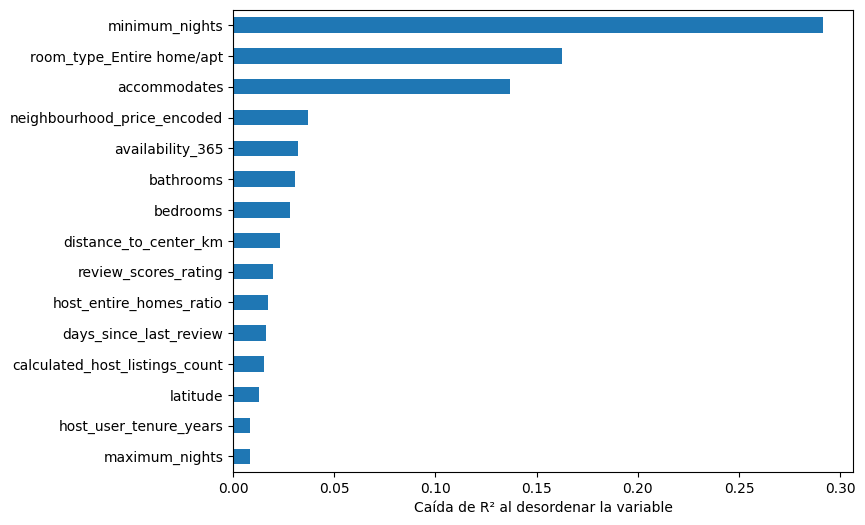

In [20]:
plt.figure(figsize=(8, 6))
importances.head(15).sort_values().plot(kind="barh")
plt.xlabel("Caída de R² al desordenar la variable")

### 10.2 Interpretación

`minimum_nights` domina con mucha diferencia (0.292), igual que en Barcelona, seguida de `room_type_Entire home/apt` (0.162) y `accommodates` (0.137) — incluso más concentrado en estas tres que en Barcelona, donde `accommodates` iba segunda y el peso se repartía algo más entre las siguientes variables. Después hay un salto grande hasta `neighbourhood_price_encoded` (0.037) y `availability_365` (0.032). Las 5 features nuevas de amenities y densidad (`has_ac`, `has_pool`, `has_dishwasher`, `n_amenities`, `n_nearby_150m`) tampoco entran en el top 15 aquí, igual que en Barcelona — a pesar de que en `01_eda.ipynb`/`02_feature_engineering.ipynb` mostraban más correlación con `log(price)` en Madrid que en Barcelona, su aporte marginal una vez el modelo ya tiene tamaño, tipo y ubicación sigue siendo pequeño.

### 10.3 SHAP: cuánto y en qué dirección

Se calcula sobre el test, igual que la importancia por permutación.

In [21]:
explainer = shap.TreeExplainer(final_pipeline.named_steps["model"])
shap_values = explainer(X_test)

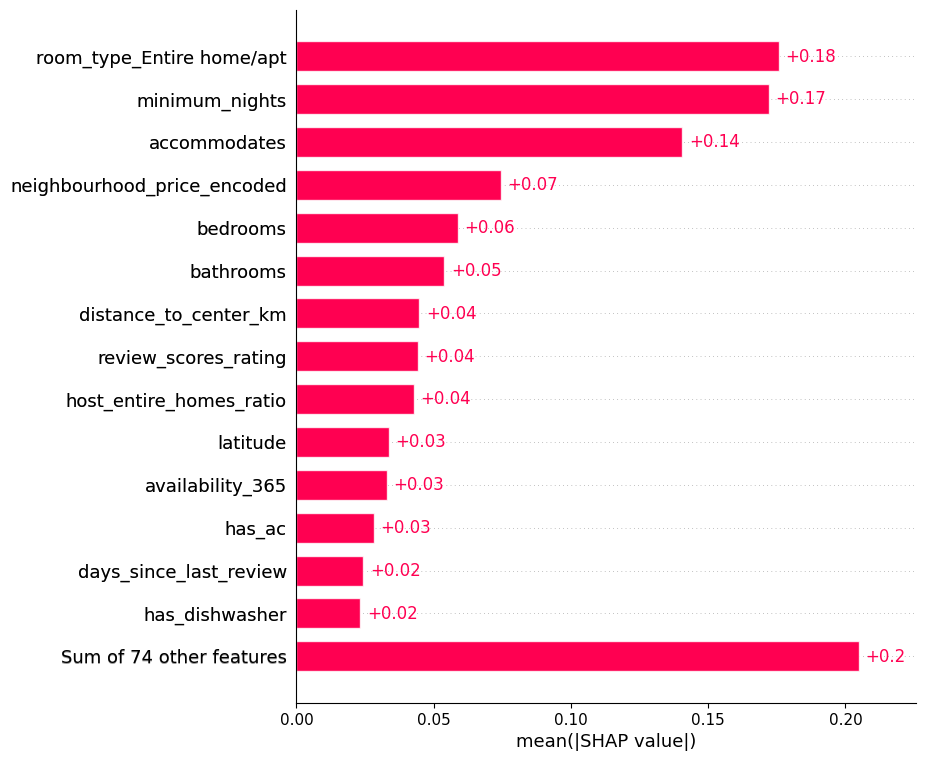

In [22]:
shap.plots.bar(shap_values, max_display=15)

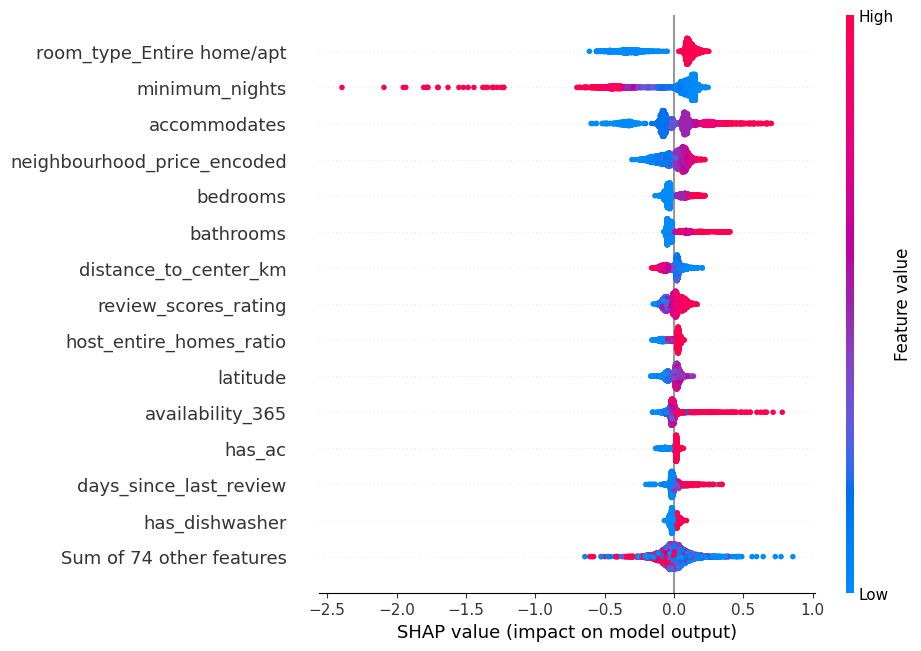

In [23]:
shap.plots.beeswarm(shap_values, max_display=15)

Mismo patrón de dirección que en Barcelona: en `minimum_nights`, los valores altos (rojo) empujan el precio hacia abajo con fuerza y los bajos (azul) lo empujan hacia arriba — el mismo efecto "alquiler de larga estancia más barato por noche" que ya se documentó en la EDA. En `room_type_Entire home/apt` y `accommodates` es al revés: valores altos empujan hacia arriba. El orden coincide con la importancia por permutación de la sección 10.1, lo que da confianza en el resultado.

### 10.4 Un ejemplo concreto

Precio real: 107.55€, predicho: 104.98€


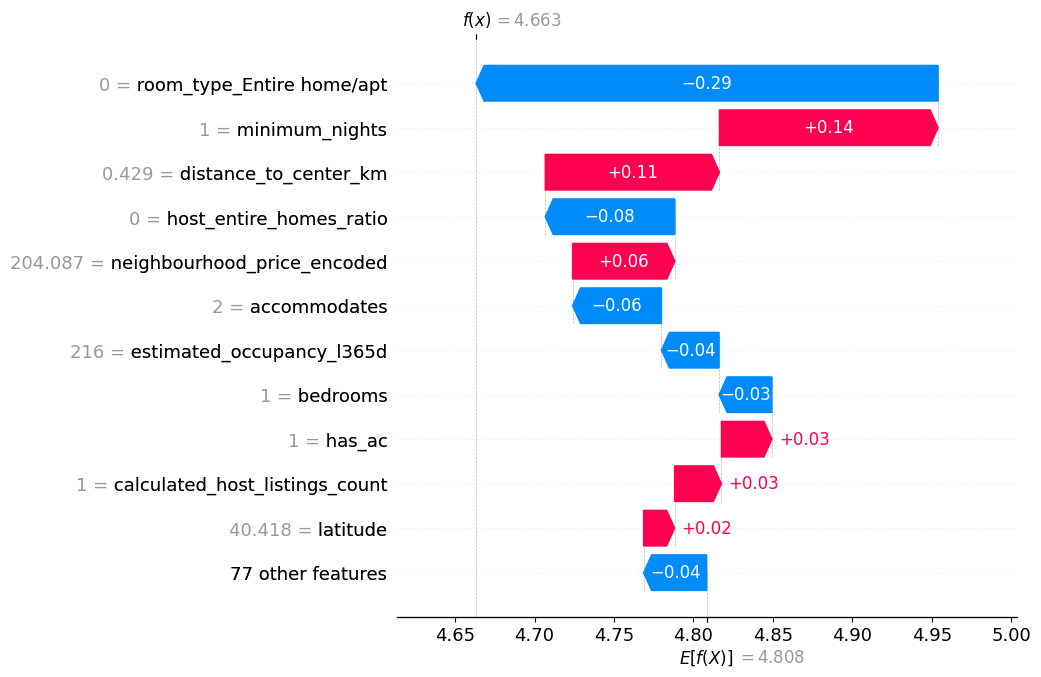

In [24]:
pred_test_all = np.expm1(final_pipeline.predict(X_test))
error_test = pred_test_all - y_test.values
median_price = y_test.median()

candidate_mask = (np.abs(y_test.values - median_price) < 20) & (np.abs(error_test) < 10)
example_pos = np.where(candidate_mask)[0][0]

print(f"Precio real: {y_test.iloc[example_pos]:.2f}€, predicho: {pred_test_all[example_pos]:.2f}€")
shap.plots.waterfall(shap_values[example_pos], max_display=12)

## 11. Guardar el modelo

### 11.1 El modelo

In [25]:
import joblib

joblib.dump(final_pipeline, f"{PROJECT_DIR}/models/madrid/price_model.pkl")

['/Users/yagocoll/Documents/Master/Airbnb/models/madrid/price_model.pkl']

### 11.2 Metadatos

In [26]:
import json
from datetime import date

metadata = {
    "model": "HistGradientBoostingRegressor",
    "date": str(date.today()),
    "target": target_col,
    "id_cols": id_cols,
    "leakage_cols_excluded": leakage_cols,
    "feature_cols": feature_cols,
    "best_params": {k.replace("model__", ""): v for k, v in hgb_search.best_params_.items()},
    "test_metrics": evaluate(y_test, pred_final, "Hist Gradient Boosting (final)"),
    "baseline_metrics": {"model": "Regresión lineal", "RMSE": 162.17, "MAE": 53.15, "R2": 0.30, "MAPE": 30.35},
}


metadata["test_metrics"]["R2_log"] = float(r2_score(y_test_log, final_pipeline.predict(X_test)))
with open(f"{PROJECT_DIR}/models/madrid/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

metadata

{'model': 'HistGradientBoostingRegressor',
 'date': '2026-09-08',
 'target': 'price',
 'id_cols': ['id', 'host_id', 'host_profile_id'],
 'leakage_cols_excluded': ['price_log',
  'price_per_accommodate',
  'price_per_min_night'],
 'feature_cols': ['host_is_superhost',
  'host_has_profile_pic',
  'host_identity_verified',
  'latitude',
  'longitude',
  'accommodates',
  'bathrooms',
  'bedrooms',
  'beds',
  'minimum_nights',
  'maximum_nights',
  'availability_365',
  'number_of_reviews',
  'number_of_reviews_ltm',
  'estimated_occupancy_l365d',
  'review_scores_rating',
  'calculated_host_listings_count',
  'reviews_per_month',
  'has_license',
  'number_of_reviews_log',
  'number_of_reviews_ltm_log',
  'reviews_per_month_log',
  'bedrooms_log',
  'beds_log',
  'bathrooms_log',
  'calculated_host_listings_count_log',
  'room_type_Entire home/apt',
  'room_type_Hotel room',
  'room_type_Private room',
  'room_type_Shared room',
  'district_Arganzuela',
  'district_Barajas',
  'district_

`R2_log` es el R² calculado sobre `log1p(price)`, la escala en la que el modelo realmente entrena (a diferencia del resto de `test_metrics`, calculadas sobre precio en euros). Se guarda como métrica adicional porque el R² en euros es muy sensible a la cola de precios altos — especialmente en Madrid, donde ambos R² pueden diferir mucho — y la app lo usa para mostrar al usuario una cifra de "cuánto explica el modelo" que sea comparable entre ciudades, en vez de una que dependa de cuántos anuncios caros haya caído del lado de test por azar del split.

## 12. Conclusiones

### El proceso, resumido

1. Se probaron 4 tipos de modelo con hiperparámetros por defecto (Ridge, Random Forest, Extra Trees, Hist Gradient Boosting). `Ridge` quedó por detrás (R²=0.29); los tres de árboles casi empatados (R² 0.37-0.38).
2. Se afinaron **los tres modelos de árboles**, no solo el que ganaba por defecto, por la misma razón que en Barcelona. El ranking no cambió: **Hist Gradient Boosting** siguió por delante tras el ajuste fino (R²=0.39 en euros vía CV, frente a 0.37 de los otros dos), con un margen ajustado pero consistente en las dos etapas.
3. El modelo final se evaluó en test **una única vez**, después de tomar todas las decisiones con validación cruzada sobre train.

### Resultado final

| Modelo | RMSE | MAE | R² | MAPE |
|---|---|---|---|---|
| Regresión lineal (baseline) | 162.17€ | 53.15€ | 0.30 | 30.35% |
| **Hist Gradient Boosting (final)** | **150.16€** | **44.62€** | **0.40** | **24.62%** |

Mejora real sobre el baseline en las cuatro métricas, aunque el nivel absoluto de R² se queda muy por debajo (0.40 frente a 0.79 en Barcelona). Comparado con train (R²=0.33, MAE=34.32€) para descartar sobreajuste severo: no hay señal de sobreajuste, de hecho train sale peor que test tanto en RMSE (201.86€ vs 150.16€) como en R² (0.33 vs 0.40), justo la dirección opuesta a la esperable. Es un efecto de que los anuncios de precio más extremo cayeron del lado de train por azar en el split, incluyendo el genuino de 22.833€/noche (ver sección 8.2), no de sobreajuste.

### Qué explica el precio, según el modelo

Permutation importance y SHAP coinciden en el orden, igual que en Barcelona: **`minimum_nights` domina con mucha diferencia sobre el resto**, seguido de `room_type_Entire home/apt` y `accommodates`. Las 5 features nuevas de amenities y densidad de anuncios (`02_feature_engineering.ipynb`) apenas pesan en esta versión del modelo, igual que en Barcelona, a pesar de mostrar más correlación individual con `log(price)` aquí.

### La gran diferencia con Barcelona: por qué el R² es tan distinto

No es que el modelo entienda peor el mercado de Madrid, las variables que más pesan y su dirección de efecto son prácticamente las mismas en las dos ciudades. Es que **el R² sobre precio en bruto es una métrica mucho más frágil en Madrid**, por la cola de precios altos genuinos que se documentó desde `01_eda.ipynb` (asimetría de `price` de 38-55 según el corte de datos, frente a un valor bastante más moderado en Barcelona) y que aquí se ve además amplificada por el azar del split train/test (sección 8.2). Si se necesitara comparar la calidad "real" del modelo entre ciudades de forma más justa, MAE o MAPE son mejores candidatos que R²/RMSE, y ahí la distancia entre Madrid (MAE 44.62€, MAPE 24.6%) y Barcelona (MAE 50.82€, MAPE 20.6%) es mucho más moderada: Madrid sale incluso algo mejor en MAE absoluto, peor en MAPE relativo (coherente con tener anuncios más baratos de media en algunas zonas, donde el mismo error absoluto pesa más en porcentaje).

### Qué queda pendiente

El análisis de errores más detallado se deja para `05_model_evaluation.ipynb`, que parte de `models/madrid/price_model.pkl` y `models/madrid/model_metadata.json` ya guardados aquí.